In [ ]:
# API KEY를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API KEY 정보로드
load_dotenv()

True

In [ ]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# .env 파일에 LANGCHAIN_API_KEY를 입력합니다.

# 프로젝트 이름을 입력합니다.
logging.langsmith("CH01-Basic")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH01-Basic


In [ ]:
!pip install -qU langchain-teddynote

## ChatOpenAI

OpenAI 사의 채팅 전용 Large Language Model(llm) 입니다.

객체를 생성할 때 다음을 옵션 값을 지정할 수 있습니다. 옵션에 대한 상세 설명은 다음과 같습니다.

`temperature`

- 사용할 샘플링 온도는 0과 2 사이에서 선택합니다. 0.8과 같은 높은 값은 출력을 더 무작위하게 만들고, 0.2와 같은 낮은 값은 출력을 더 집중되고 결정론적으로 만듭니다.

`max_tokens`

- 채팅 완성에서 생성할 토큰의 최대 개수입니다.

`model_name`: 적용 가능한 모델 리스트

| 모델 계열       | 모델명 (API Name) | 입력       | 컨텍스트 윈도우  | 최대 출력 토큰 | 지식 마감일 (Cutoff) | 가격                  |
| :---------- | :------------- | :------- | :-------- | :------- | :-------------- | :------------------------------ |
| **GPT-5**   | `gpt-5`        | 텍스트, 이미지 | 400,000   | 128,000  | 2024년 9월 30일    | **입력:** $1.25<br>**출력:** $10.00 |
|             | `gpt-5-mini`   | 텍스트, 이미지 | 400,000   | 128,000  | 2024년 5월 31일    | **입력:** $0.25<br>**출력:** $2.00  |
|             | `gpt-5-nano`   | 텍스트, 이미지 | 400,000   | 128,000  | 2024년 5월 31일    | **입력:** $0.05<br>**출력:** $0.40  |
| **GPT-4.1** | `gpt-4.1`      | 텍스트, 이미지 | 1,047,576 | 32,768   | 2024년 6월 1일     | **입력:** $2.00<br>**출력:** $8.00  |
|             | `gpt-4.1-mini` | 텍스트, 이미지 | 1,047,576 | 32,768   | 2024년 6월 1일     | **입력:** $0.40<br>**출력:** $1.60  |
|             | `gpt-4.1-nano` | 텍스트, 이미지 | 1,047,576 | 32,768   | 2024년 6월 1일     | **입력:** $0.10<br>**출력:** $0.40  |
| **GPT-4o**  | `gpt-4o`       | 텍스트, 이미지 | 128,000   | 16,384   | 2023년 10월 1일    | **입력:** $2.50<br>**출력:** $10.00 |
|             | `gpt-4o-mini`  | 텍스트, 이미지 | 128,000   | 16,384   | 2023년 10월 1일    | **입력:** $0.15<br>**출력:** $0.60  |

![gpt-models.png](./images/gpt-models3-202508.png)

- 링크: https://platform.openai.com/docs/models

In [ ]:
from langchain_openai import ChatOpenAI

# 객체 생성
llm = ChatOpenAI(
    temperature=0.1,  # 창의성 (0.0 ~ 2.0)
    model_name="gpt-4o",  # 모델명
)

# 질의내용
question = "독일의 수도는 어디인가요?" # 대한민국


# 질의
print(f"[LLM의 답변]: {llm.invoke(question)}")

c:\Users\jinmi\AppData\Local\pypoetry\Cache\virtualenvs\langchain-kr-ujm_vYdK-py3.11\Lib\site-packages\pydantic\v1\main.py:1054: UserWarning: LangSmith now uses UUID v7 for run and trace identifiers. This warning appears when passing custom IDs. Please use: from langsmith import uuid7
            id = uuid7()
Future versions will require UUID v7.
  input_data = validator(cls_, input_data)


[LLM의 답변]: content='독일의 수도는 베를린입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 16, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-Cx4rIktKd2OUqKMonPSps0R15DAvm', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--d7a4117b-8e24-48a3-ad7d-33d4e502c759-0' usage_metadata={'input_tokens': 16, 'output_tokens': 10, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


### 답변의 형식(AI Message)

In [ ]:
# 질의내용
question = "독일의 수도는 어디인가요?" #대한민국

# 질의
response = llm.invoke(question)

In [ ]:
response

AIMessage(content='독일의 수도는 베를린입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 16, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-Cx4rVaViKCDJ0wmG6XpoNJ0ARrQBX', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--8c7e2dee-e62a-4aa3-9181-1c964197ad46-0', usage_metadata={'input_tokens': 16, 'output_tokens': 10, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
response.content

'독일의 수도는 베를린입니다.'

In [ ]:
response.response_metadata

{'token_usage': {'completion_tokens': 10,
  'prompt_tokens': 16,
  'total_tokens': 26,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_name': 'gpt-4o-2024-08-06',
 'system_fingerprint': 'fp_deacdd5f6f',
 'id': 'chatcmpl-Cx4rVaViKCDJ0wmG6XpoNJ0ARrQBX',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

### LogProb 활성화

주어진 텍스트에 대한 모델의 **토큰 확률의 로그 값** 을 의미합니다. 토큰이란 문장을 구성하는 개별 단어나 문자 등의 요소를 의미하고, 확률은 **모델이 그 토큰을 예측할 확률**을 나타냅니다.

In [ ]:
# 객체 생성
llm_with_logprob = ChatOpenAI(
    temperature=0.1,  # 창의성 (0.0 ~ 2.0)
    max_tokens=2048,  # 최대 토큰수
    model_name="gpt-4.1-nano",  # 모델명
).bind(logprobs=True)

In [ ]:
# 질의내용
question = "독일의 수도는 어디인가요?" #대한민국

# 질의
response = llm_with_logprob.invoke(question)

In [ ]:
# 결과 출력
response.response_metadata

{'token_usage': {'completion_tokens': 10,
  'prompt_tokens': 16,
  'total_tokens': 26,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_name': 'gpt-4.1-nano-2025-04-14',
 'system_fingerprint': 'fp_7f8eb7d1f9',
 'id': 'chatcmpl-Cx4rbGtOlOlnhTps9ABiAV8qGuCmx',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': {'content': [{'token': '독',
    'bytes': [235, 143, 133],
    'logprob': -4.751746746478602e-05,
    'top_logprobs': []},
   {'token': '일',
    'bytes': [236, 157, 188],
    'logprob': -2.1008713702030946e-06,
    'top_logprobs': []},
   {'token': '의',
    'bytes': [236, 157, 152],
    'logprob': -5.438573680294212e-06,
    'top_logprobs': []},
   {'token': ' 수도',
    'bytes': [32, 236, 136, 152, 235, 143, 132],
    'logprob': -3.404745439183898e-05,
    'top_logprobs': []},
   {'token': '는'

### 스트리밍 출력

스트리밍 옵션은 질의에 대한 답변을 실시간으로 받을 때 유용합니다.

In [ ]:
# 스트림 방식으로 질의
# answer 에 스트리밍 답변의 결과를 받습니다.
answer = llm.stream("독일의 아름다운 관광지 10곳과 주소를 알려주세요!")

In [ ]:
# 스트리밍 방식으로 각 토큰을 출력합니다. (실시간 출력)
final_answer = ""
for token in answer:
    print(token.content, end="", flush=True)
    final_answer += token.content

독일은 다양한 문화와 역사를 자랑하는 아름다운 관광지로 가득합니다. 다음은 독일의 대표적인 관광지 10곳과 그에 대한 간략한 설명입니다. 주소는 일반적인 위치를 기준으로 제공됩니다.

1. **브란덴부르크 문 (Brandenburger Tor)**
   - 위치: Pariser Platz, 10117 Berlin
   - 설명: 베를린의 상징적인 랜드마크로, 독일의 통일을 상징합니다.

2. **쾰른 대성당 (Kölner Dom)**
   - 위치: Domkloster 4, 50667 Köln
   - 설명: 고딕 양식의 걸작으로, 유네스코 세계문화유산에 등재되어 있습니다.

3. **네우슈반슈타인 성 (Schloss Neuschwanstein)**
   - 위치: Neuschwansteinstraße 20, 87645 Schwangau
   - 설명: 디즈니 성의 모델로 유명하며, 바이에른의 아름다운 자연 속에 위치해 있습니다.

4. **하이델베르크 성 (Heidelberger Schloss)**
   - 위치: Schlosshof 1, 69117 Heidelberg
   - 설명: 낭만적인 도시 하이델베르크에 위치한 중세 성으로, 아름다운 경관을 자랑합니다.

5. **로텐부르크 오프 데어 타우버 (Rothenburg ob der Tauber)**
   - 위치: Rothenburg ob der Tauber, Bavaria
   - 설명: 중세 도시의 모습을 그대로 간직한 독일의 가장 잘 보존된 도시 중 하나입니다.

6. **함부르크 미니아투어 원더랜드 (Miniatur Wunderland)**
   - 위치: Kehrwieder 2-4/Block D, 20457 Hamburg
   - 설명: 세계 최대의 철도 모형 전시관으로, 다양한 테마의 미니어처 세계를 탐험할 수 있습니다.

7. **슈바르츠발트 (Black Forest)**
   - 위치: Baden-Württemberg
   - 설명: 울창한 숲과 그림 같은 마을로 유명하며, 독일의 전통적인 

In [ ]:
final_answer

'독일은 다양한 문화와 역사를 자랑하는 아름다운 관광지로 가득합니다. 다음은 독일의 대표적인 관광지 10곳과 그에 대한 간략한 설명입니다. 주소는 일반적인 위치를 기준으로 제공됩니다.\n\n1. **브란덴부르크 문 (Brandenburger Tor)**\n   - 위치: Pariser Platz, 10117 Berlin\n   - 설명: 베를린의 상징적인 랜드마크로, 독일의 통일을 상징합니다.\n\n2. **쾰른 대성당 (Kölner Dom)**\n   - 위치: Domkloster 4, 50667 Köln\n   - 설명: 고딕 양식의 걸작으로, 유네스코 세계문화유산에 등재되어 있습니다.\n\n3. **네우슈반슈타인 성 (Schloss Neuschwanstein)**\n   - 위치: Neuschwansteinstraße 20, 87645 Schwangau\n   - 설명: 디즈니 성의 모델로 유명하며, 바이에른의 아름다운 자연 속에 위치해 있습니다.\n\n4. **하이델베르크 성 (Heidelberger Schloss)**\n   - 위치: Schlosshof 1, 69117 Heidelberg\n   - 설명: 낭만적인 도시 하이델베르크에 위치한 중세 성으로, 아름다운 경관을 자랑합니다.\n\n5. **로텐부르크 오프 데어 타우버 (Rothenburg ob der Tauber)**\n   - 위치: Rothenburg ob der Tauber, Bavaria\n   - 설명: 중세 도시의 모습을 그대로 간직한 독일의 가장 잘 보존된 도시 중 하나입니다.\n\n6. **함부르크 미니아투어 원더랜드 (Miniatur Wunderland)**\n   - 위치: Kehrwieder 2-4/Block D, 20457 Hamburg\n   - 설명: 세계 최대의 철도 모형 전시관으로, 다양한 테마의 미니어처 세계를 탐험할 수 있습니다.\n\n7. **슈바르츠발트 (Black Forest)**\n   - 위치: Baden-Württemberg\n   - 설명: 울창한

In [ ]:
from langchain_teddynote.messages import stream_response

# 스트림 방식으로 질의
# answer 에 스트리밍 답변의 결과를 받습니다.
answer = llm.stream("독일의 아름다운 관광지 10곳과 주소를 알려주세요!")
final_answer2 = stream_response(answer)

독일은 다양한 문화와 역사를 자랑하는 아름다운 관광지로 가득합니다. 다음은 독일의 아름다운 관광지 10곳과 그 주소입니다.

1. **노이슈반슈타인 성 (Schloss Neuschwanstein)**
   - 주소: Neuschwansteinstraße 20, 87645 Schwangau, Germany

2. **브란덴부르크 문 (Brandenburger Tor)**
   - 주소: Pariser Platz, 10117 Berlin, Germany

3. **쾰른 대성당 (Kölner Dom)**
   - 주소: Domkloster 4, 50667 Köln, Germany

4. **하이델베르크 성 (Heidelberger Schloss)**
   - 주소: Schlosshof 1, 69117 Heidelberg, Germany

5. **로텐부르크 오프 데어 타우버 (Rothenburg ob der Tauber)**
   - 주소: Rothenburg ob der Tauber, Bavaria, Germany

6. **함부르크 미니어처 원더랜드 (Miniatur Wunderland)**
   - 주소: Kehrwieder 2-4/Block D, 20457 Hamburg, Germany

7. **베를린 박물관 섬 (Museumsinsel)**
   - 주소: Bodestraße 1-3, 10178 Berlin, Germany

8. **슈바르츠발트 (Black Forest)**
   - 주소: Baden-Württemberg, Germany (특정 주소 없음, 지역명)

9. **작센 스위스 국립공원 (Saxon Switzerland National Park)**
   - 주소: Sächsische Schweiz, Saxony, Germany (특정 주소 없음, 지역명)

10. **뮌헨 마리엔 광장 (Marienplatz)**
    - 주소: Marienplatz, 80331 München, Germany

이 관광지들은 독일의 역사, 문화, 자연의 아

## 프롬프트 캐싱

- 참고 링크: https://platform.openai.com/docs/guides/prompt-caching

프롬프트 캐싱 기능을 활용하면 반복하여 동일하게 입력으로 들어가는 토큰에 대한 비용을 아낄 수 있습니다.

다만, 캐싱에 활용할 토큰은 고정된 PREFIX 를 주는 것이 권장됩니다.

아래의 예시에서는 `<PROMPT_CACHING>` 부분에 고정된 토큰을 주어 캐싱을 활용하는 방법을 설명합니다.

## 멀티모달 모델(이미지 인식)

멀티모달은 여러 가지 형태의 정보(모달)를 통합하여 처리하는 기술이나 접근 방식을 의미합니다. 이는 다음과 같은 다양한 데이터 유형을 포함할 수 있습니다.

- 텍스트: 문서, 책, 웹 페이지 등의 글자로 된 정보
- 이미지: 사진, 그래픽, 그림 등 시각적 정보
- 오디오: 음성, 음악, 소리 효과 등의 청각적 정보
- 비디오: 동영상 클립, 실시간 스트리밍 등 시각적 및 청각적 정보의 결합

`gpt-4.1` 모델은 이미지 인식 기능(Vision) 이 추가되어 있는 모델입니다.

In [ ]:
from langchain_teddynote.models import MultiModal
from langchain_teddynote.messages import stream_response

# 객체 생성
llm = ChatOpenAI(
    temperature=0.1,  # 창의성 (0.0 ~ 2.0)
    model_name="gpt-4o",  # 모델명
)

# 멀티모달 객체 생성
multimodal_llm = MultiModal(llm)


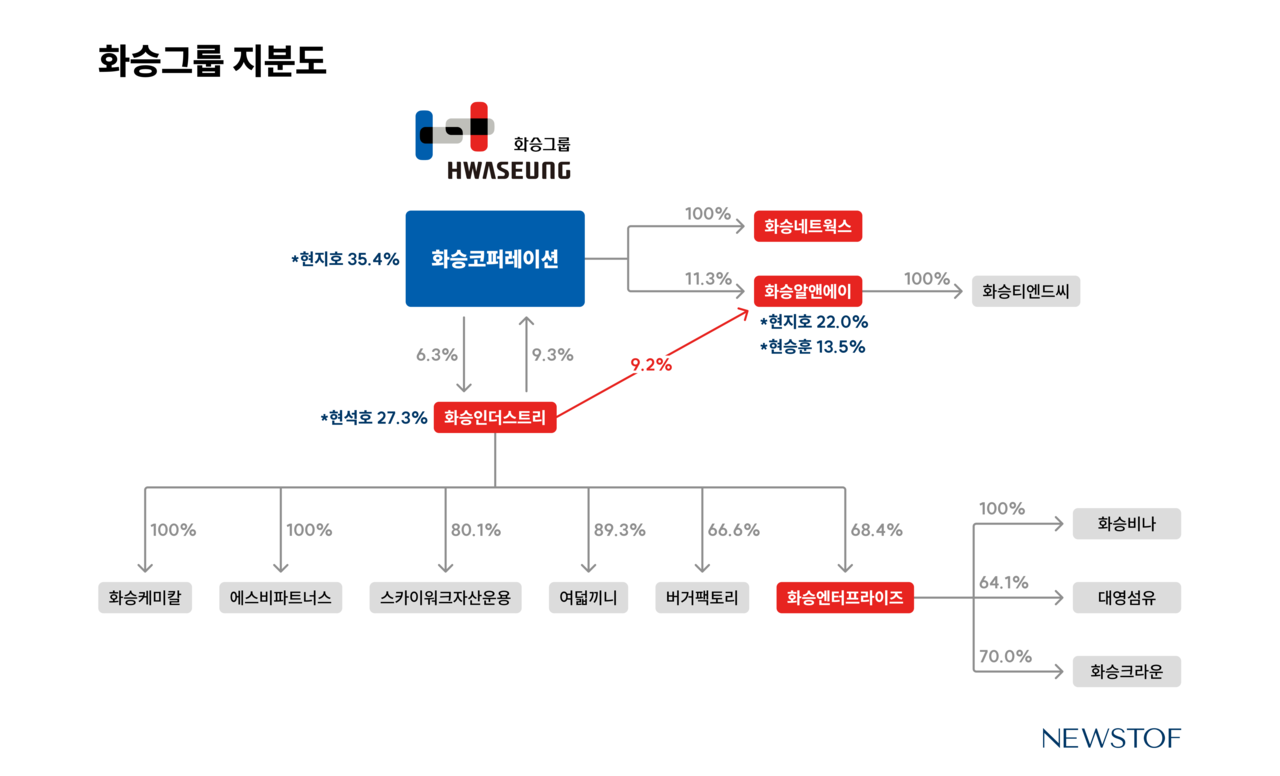

The image is a corporate structure chart for the Hwaseung Group, detailing ownership percentages and relationships between various entities within the group.

### Main Entities:

1. **Hwaseung Corporation (화승코퍼레이션)**
   - Central entity in the chart.
   - Owned 35.4% by an individual named 현지호.

2. **Hwaseung Industry (화승인더스트리)**
   - Owned 27.3% by 현석호.
   - Holds stakes in several subsidiaries:
     - **Hwaseung Chemical (화승케미칼)**: 100%
     - **SB Partners (에스비파트너스)**: 100%
     - **Skywalk Asset Management (스카이워크자산운용)**: 80.1%
     - **Yeodeumgni (여덤끄니)**: 89.3%
     - **Burger Factory (버거팩토리)**: 66.6%
     - **Hwaseung Enterprises (화승엔터프라이즈)**: 68.4%

3. **Hwaseung Networks (화승네트웍스)**
   - Fully owned by Hwaseung Corporation.

4. **Hwaseung L&AE (화승알앤에이)**
   - 11.3% owned by Hwaseung Corporation.
   - Additional ownership by 현지호 (22.0%) and 현승훈 (13.5%).
   - Fully owns Hwaseung T&C (화승티앤드씨).

5. **Hwaseung Enterprises (화승엔터프라이즈)**
   - Holds stakes in:
     - **Hwaseung Vina (화승비

In [ ]:
# 샘플 이미지 주소(웹사이트로 부터 바로 인식)
IMAGE_URL = "https://cdn.newstopkorea.com/news/photo/202502/26323_28323_452.png"
#"https://t3.ftcdn.net/jpg/03/77/33/96/360_F_377339633_Rtv9I77sSmSNcev8bEcnVxTHrXB4nRJ5.jpg"

# 이미지 파일로 부터 질의
answer = multimodal_llm.stream(IMAGE_URL)
# 스트리밍 방식으로 각 토큰을 출력합니다. (실시간 출력)
stream_response(answer)


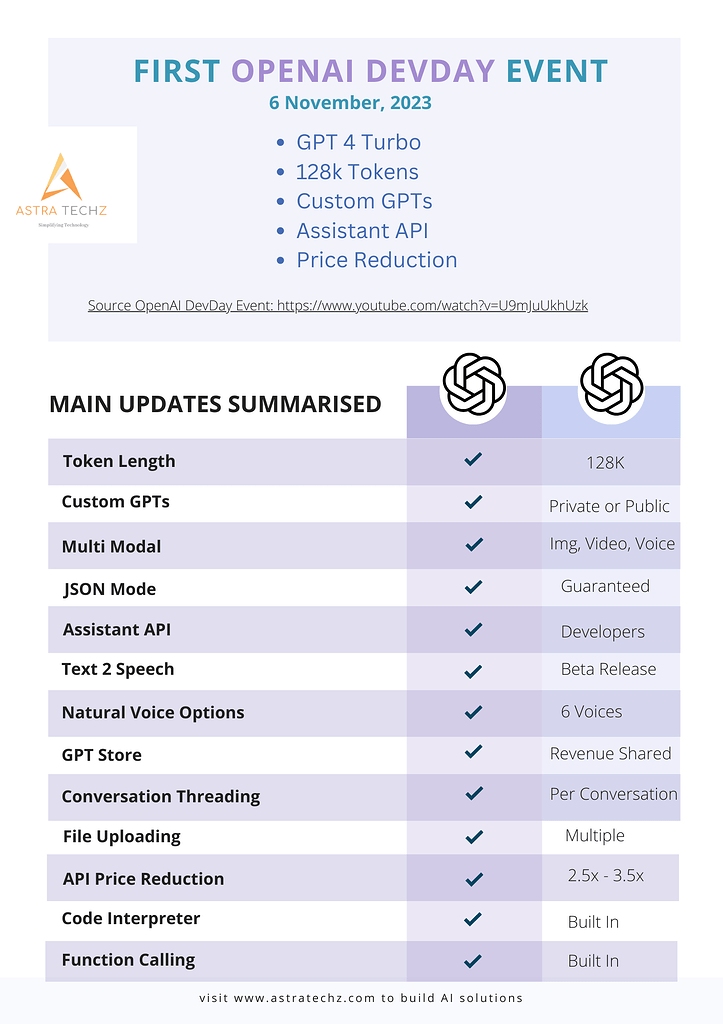

The image is an infographic summarizing the key updates from the "First OpenAI DevDay Event" held on November 6, 2023. It highlights several new features and improvements related to OpenAI's offerings. Here's a detailed breakdown:

### Event Details
- **Title:** First OpenAI DevDay Event
- **Date:** November 6, 2023
- **Key Announcements:**
  - GPT 4 Turbo
  - 128k Tokens
  - Custom GPTs
  - Assistant API
  - Price Reduction

### Main Updates Summarized

1. **Token Length:**
   - Increased to 128K tokens, allowing for longer inputs and outputs.

2. **Custom GPTs:**
   - Options for creating private or public custom GPT models.

3. **Multi Modal:**
   - Supports images, video, and voice inputs, enhancing versatility.

4. **JSON Mode:**
   - Guaranteed JSON output for structured data handling.

5. **Assistant API:**
   - Available for developers, enabling integration into applications.

6. **Text to Speech:**
   - Beta release of text-to-speech capabilities.

7. **Natural Voice Options:*

In [ ]:
# 로컬 PC 에 저장되어 있는 이미지의 경로 입력
IMAGE_PATH_FROM_FILE = "./images/sample-image.png"

# 이미지 파일로 부터 질의(스트림 방식)
answer = multimodal_llm.stream(IMAGE_PATH_FROM_FILE)
# 스트리밍 방식으로 각 토큰을 출력합니다. (실시간 출력)
stream_response(answer)

## System, User 프롬프트 수정

In [ ]:
system_prompt = """당신은 표(재무제표) 를 해석하는 금융 AI 어시스턴트 입니다.
당신의 임무는 주어진 테이블 형식의 재무제표를 바탕으로 흥미로운 사실을 정리하여 친절하게 한글로 답변하는 것입니다."""

user_prompt = """당신에게 주어진 표는 회사의 재무제표 입니다. 흥미로운 사실을 정리하여 답변하세요."""

# 멀티모달 객체 생성
multimodal_llm_with_prompt = MultiModal(
    llm, system_prompt=system_prompt, user_prompt=user_prompt
)


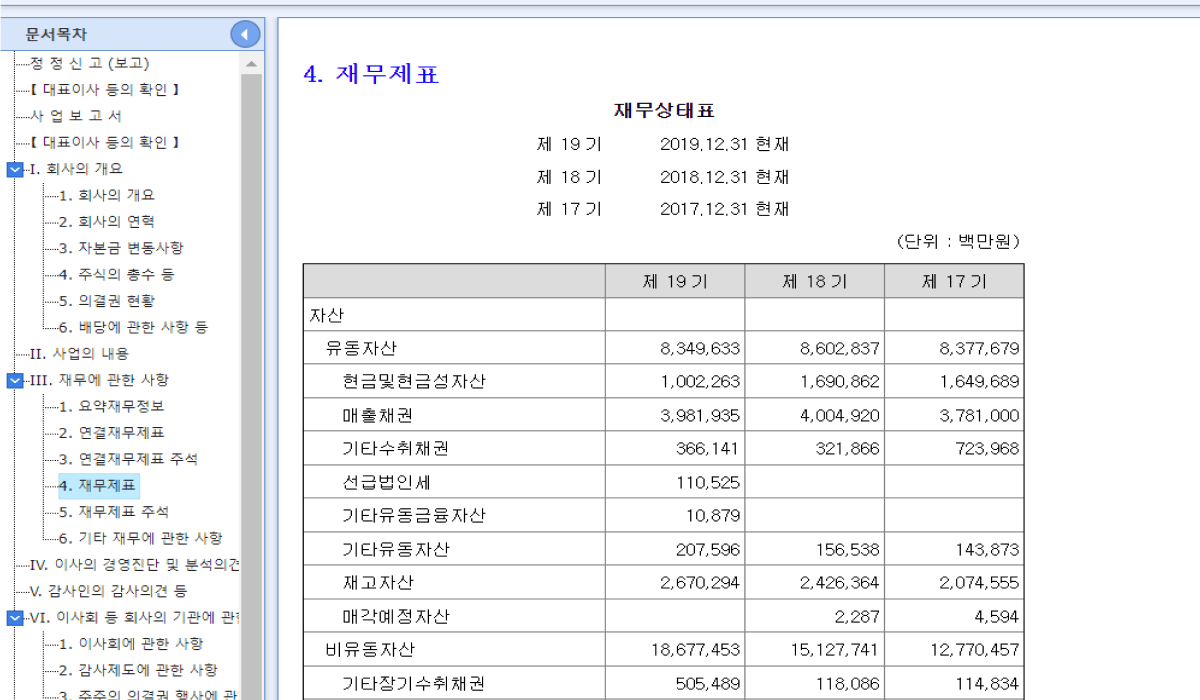

주어진 재무상태표를 분석한 결과, 다음과 같은 흥미로운 사실을 발견할 수 있습니다:

1. **유동자산 감소**: 제 19기(2019년)에는 유동자산이 8,349,633백만원으로, 전기(2018년) 대비 감소하였습니다. 이는 주로 현금 및 현금성 자산의 감소에 기인합니다.

2. **현금 및 현금성 자산 감소**: 제 19기에는 현금 및 현금성 자산이 1,002,263백만원으로, 전기 대비 큰 폭으로 감소하였습니다. 이는 회사의 유동성에 영향을 미칠 수 있는 중요한 변화입니다.

3. **매출채권 감소**: 매출채권은 제 19기에 3,981,935백만원으로, 전기 대비 소폭 감소하였습니다. 이는 매출 회수의 효율성에 영향을 줄 수 있습니다.

4. **기타수취채권 증가**: 기타수취채권은 제 19기에 366,141백만원으로, 전기 대비 증가하였습니다. 이는 회사의 채권 관리에 변동이 있었음을 시사합니다.

5. **비유동자산 증가**: 비유동자산은 제 19기에 18,677,453백만원으로, 전기 대비 증가하였습니다. 이는 장기적인 투자나 자산의 증가를 나타낼 수 있습니다.

6. **기타장기수취채권 증가**: 기타장기수취채권은 제 19기에 505,489백만원으로, 전기 대비 증가하였습니다. 이는 장기적인 채권 회수 계획이 있음을 나타낼 수 있습니다.

이러한 변화들은 회사의 재무 상태와 전략적 방향에 중요한 영향을 미칠 수 있습니다.

In [ ]:
# 로컬 PC 에 저장되어 있는 이미지의 경로 입력
IMAGE_PATH_FROM_FILE = "https://storage.googleapis.com/static.fastcampus.co.kr/prod/uploads/202212/080345-661/kwon-01.png"

# 이미지 파일로 부터 질의(스트림 방식)
answer = multimodal_llm_with_prompt.stream(IMAGE_PATH_FROM_FILE)

# 스트리밍 방식으로 각 토큰을 출력합니다. (실시간 출력)
stream_response(answer)